In [1]:
# Imports and repo setup for F switch_on with a continuous Rzz orientation constraint.
from pathlib import Path
from collections import Counter
from dataclasses import asdict, dataclass
from io import BytesIO
import json
import os
import sys
import time

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import torch
import pybullet as p
from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "calvin_experiments" / "calvin_rollout_utils.py").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not find guided-diffusion repo root")
    REPO_ROOT = REPO_ROOT.parent

for path in [REPO_ROOT, REPO_ROOT / "robomimic", REPO_ROOT / "calvin" / "calvin_env", REPO_ROOT / "calvin_experiments"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import robomimic.envs  # noqa: F401
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.python_utils as PyUtils
import robomimic.utils.torch_utils as TorchUtils

from calvin_experiments import calvin_rollout_utils as CRU
from calvin_experiments.label_calvin_world_model import label_scene_states_for_names
from calvin_experiments.train_dynamics_world_model import load_dynamics_model_for_eval

print("repo:", REPO_ROOT)
print("cuda:", torch.cuda.is_available())


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


repo: /home/moritz/src/guided-diffusion
cuda: True


In [2]:
# Load the diffusion policy, automaton model, and local dynamics model for Rzz guidance.
DEVICE = TorchUtils.get_torch_device(try_to_use_cuda=True)

POLICY_CKPT_PATH = REPO_ROOT / "outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth"
AUTOMATON_CKPT_PATH = REPO_ROOT / "outputs/calvin/automaton_world_model/h8_sh64_ah96_lh16_hh128_lr0.0003_epochs80_2026-05-05_20-38-38"
DYNAMICS_CKPT_PATH = REPO_ROOT / "outputs/calvin/dynamics_world_model/hd512_depth4_drop0.02_lr0.0005_epochs70_2026-05-06_01-42-08"
SCENE_CONFIG_PATH = REPO_ROOT / "calvin_experiments/configs/blocks_hidden.json"
VISUALIZATION_CONFIG_PATH = REPO_ROOT / "calvin_experiments/configs/visualization_freiburg_style.json"
OUTPUT_ROOT = REPO_ROOT / "outputs/calvin/paper_stls/F_switch_G_Rzz"

policy, ckpt_dict = FileUtils.policy_from_checkpoint(ckpt_path=str(POLICY_CKPT_PATH), device=DEVICE, verbose=False)
policy_epoch = CRU.policy_epoch_from_checkpoint(POLICY_CKPT_PATH)
scene_cfg = CRU.load_json_config(SCENE_CONFIG_PATH)
video_cfg = CRU.load_json_config(VISUALIZATION_CONFIG_PATH)

automaton_model, automaton_stats, automaton_meta = CRU.automaton_model_for_eval(AUTOMATON_CKPT_PATH, DEVICE)
label_names = list(automaton_meta["label_names"])
label_thresholds = automaton_meta.get("label_thresholds")
dynamics_model, dynamics_stats, dynamics_ckpt, dynamics_meta = load_dynamics_model_for_eval(DYNAMICS_CKPT_PATH, device=DEVICE)
dynamics_model.eval()
dynamics_stats_t = {k: torch.as_tensor(v, device=DEVICE, dtype=torch.float32).unsqueeze(0) for k, v in dynamics_stats.items()}

print("device:", DEVICE)
print("labels:", label_names)
print("policy:", POLICY_CKPT_PATH)
print("automaton:", AUTOMATON_CKPT_PATH)
print("dynamics:", DYNAMICS_CKPT_PATH)



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['proprio']
using obs modality: rgb with keys: ['third_person', 'eye_in_hand']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
number of parameters: 6.931892e+07
device: cuda:0
labels: ['switch_on', 'switch_off', 'button_on', 'button_off', 'button_pressed', 'drawer_open', 'drawer_closed', 'door_left', 'door_right']
target: 0 switch_on
policy: /home/moritz/src/guided-diffusion/outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth
automaton: /home/moritz/src/guided-diffusion/outputs/calvin/automaton_world_model/h8_sh64_ah96_lh16_hh128_lr0.0003_epochs80_2026-05-05_20-38-38
dynamics: /home/moritz/src/guided-diffusion/outputs/calvin/dynamics_world_model/hd512_depth4_drop0.02_lr0.0005_epochs70_2026-05-06_01-42-08


In [3]:
# Rollout helpers and automaton sample-and-rank utilities.
env = None
base_env_state = None

def current_automaton_state_and_label(env):
    state = env.get_state()
    robot = np.asarray(state["robot"], dtype=np.float32).reshape(-1)
    scene = np.asarray(state["scene"], dtype=np.float32).reshape(-1)
    automaton_state = np.concatenate([robot, scene]).astype(np.float32)
    automaton_label = label_scene_states_for_names(scene[None, :], label_names, label_thresholds)[0].astype(np.float32)
    return automaton_state, automaton_label

def opposite_label_idx(target_label_idx):
    opposites = {
        "switch_on": "switch_off", "switch_off": "switch_on",
        "button_on": "button_off", "button_off": "button_on",
        "drawer_open": "drawer_closed", "drawer_closed": "drawer_open",
        "door_left": "door_right", "door_right": "door_left",
    }
    name = opposites.get(label_names[int(target_label_idx)])
    return None if name is None or name not in label_names else label_names.index(name)

def goal_label_indices(goal_names):
    missing = [name for name in goal_names if name not in label_names]
    if missing:
        raise KeyError(f"Unknown goal label(s): {missing}. Available labels: {label_names}")
    return [label_names.index(name) for name in goal_names]

def score_label_probs(label_probs, target_label_idx):
    scores = np.asarray(label_probs, dtype=np.float32)[..., int(target_label_idx)].copy()
    opp = opposite_label_idx(target_label_idx)
    if opp is not None:
        scores -= np.asarray(label_probs, dtype=np.float32)[..., opp]
    return scores

def score_goal_probs(label_probs, goal_label_idxs):
    goal_label_idxs = [int(idx) for idx in goal_label_idxs]
    per_goal_scores = np.stack([score_label_probs(label_probs, idx) for idx in goal_label_idxs], axis=-1)
    best_goal_pos = np.argmax(per_goal_scores, axis=-1)
    flat_scores = per_goal_scores.reshape(-1, per_goal_scores.shape[-1])
    best_scores = flat_scores[np.arange(flat_scores.shape[0]), best_goal_pos.reshape(-1)].reshape(best_goal_pos.shape)
    return best_scores.astype(np.float32), best_goal_pos.astype(np.int64), per_goal_scores.astype(np.float32)

def repeat_obs_batch(obs_tensor, n):
    if int(n) == 1:
        return obs_tensor
    return {k: v.repeat((int(n),) + (1,) * (v.ndim - 1)) for k, v in obs_tensor.items()}

def unnormalize_action_sequence(action_sequence):
    action_np = CRU.to_numpy(action_sequence).astype(np.float32)
    if policy.action_normalization_stats is None:
        return action_np
    original_shape = action_np.shape
    flat_actions = action_np.reshape(-1, original_shape[-1])
    action_keys = policy.policy.global_config.train.action_keys
    action_shapes = {k: policy.action_normalization_stats[k]["offset"].shape[1:] for k in policy.action_normalization_stats}
    action_dict = PyUtils.vector_to_action_dict(flat_actions, action_shapes=action_shapes, action_keys=action_keys)
    action_dict = ObsUtils.unnormalize_dict(action_dict, normalization_stats=policy.action_normalization_stats)
    return PyUtils.action_dict_to_vector(action_dict, action_keys=action_keys).reshape(original_shape)

def predict_future_label_probs(automaton_state, automaton_label, action_chunks):
    action_chunks = np.asarray(action_chunks, dtype=np.float32)
    n_candidates, _, action_dim = action_chunks.shape
    action_chunk_dim = len(automaton_stats["actions_mean"])
    automaton_horizon = action_chunk_dim // action_dim
    scored_chunks = action_chunks[:, :automaton_horizon, :].reshape(n_candidates, -1)
    states = np.repeat(np.asarray(automaton_state, dtype=np.float32)[None, :], n_candidates, axis=0)
    labels = np.repeat(np.asarray(automaton_label, dtype=np.float32)[None, :], n_candidates, axis=0)
    states_t = torch.as_tensor((states - automaton_stats["states_mean"]) / automaton_stats["states_std"], device=DEVICE, dtype=torch.float32)
    actions_t = torch.as_tensor((scored_chunks - automaton_stats["actions_mean"]) / automaton_stats["actions_std"], device=DEVICE, dtype=torch.float32)
    labels_t = torch.as_tensor(labels, device=DEVICE, dtype=torch.float32)
    with torch.no_grad():
        probs = torch.sigmoid(automaton_model(states_t, actions_t, labels_t)).detach().cpu().numpy()
    return probs, automaton_horizon

def rzz_from_euler_xyz_np(euler_xyz):
    euler_xyz = np.asarray(euler_xyz, dtype=np.float32)
    # Same convention as train_dynamics_world_model: R = Rz(yaw) @ Ry(pitch) @ Rx(roll).
    return np.cos(euler_xyz[..., 1]) * np.cos(euler_xyz[..., 0])

def angle_diff(a, b):
    return float(np.arctan2(np.sin(a - b), np.cos(a - b)))

def robot_with_target_rzz(robot, rzz_spec, env=None):
    robot = np.asarray(robot, dtype=np.float32).copy()
    original_rzz = float(rzz_from_euler_xyz_np(robot[3:6]))
    roll, pitch, yaw = [float(v) for v in robot[3:6]]
    cos_pitch = float(np.cos(pitch))
    if abs(cos_pitch) < 1e-4:
        raise ValueError(f"Cannot solve reset roll for Rzz when cos(pitch) is near zero: pitch={pitch}")
    cos_roll = float(np.clip(rzz_spec.target / cos_pitch, -1.0, 1.0))
    candidate_abs = float(np.arccos(cos_roll))
    candidates = [candidate_abs, -candidate_abs]
    new_roll = min(candidates, key=lambda cand: abs(angle_diff(cand, roll)))
    robot[3:6] = np.asarray([new_roll, pitch, yaw], dtype=np.float32)

    reset_info = {
        "enabled": True,
        "old_euler_xyz": [roll, pitch, yaw],
        "new_euler_xyz": [float(robot[3]), float(robot[4]), float(robot[5])],
        "old_rzz": original_rzz,
        "target_rzz": float(rzz_spec.target),
        "requested_rzz": float(rzz_from_euler_xyz_np(robot[3:6])),
        "ik_applied": False,
    }
    if env is not None:
        calvin_env = CRU.get_calvin_unwrapped_env(env)
        target_quat = p.getQuaternionFromEuler(robot[3:6].tolist())
        ik_joints = np.asarray(calvin_env.robot.mixed_ik.get_ik(robot[:3], target_quat), dtype=np.float32)[:7]
        if ik_joints.shape[0] != 7 or not np.all(np.isfinite(ik_joints)):
            raise RuntimeError(f"IK failed for target TCP pose: joints={ik_joints}")
        robot[7:14] = ik_joints
        reset_info["ik_applied"] = True
        reset_info["ik_joints"] = ik_joints.tolist()
    return robot, reset_info

def rollout_policy_once(seed, action_sampler, output_dir, rollout_tag, horizon=150, save_video=True, stop_on_behavior=True, initialize_robot_rzz=False, rzz_spec=None):
    global env, base_env_state
    CRU.drop_env_quietly(globals(), name="env")
    env, base_env_state = CRU.load_fresh_env_from_checkpoint(ckpt_dict, seed=int(seed), suppress_output=True)
    fixed_scene, fixed_robot, active_scene_cfg = CRU.fixed_scene_robot_from_config(base_env_state, SCENE_CONFIG_PATH)
    reset_rzz = {"enabled": False, "old_rzz": float(rzz_from_euler_xyz_np(fixed_robot[3:6]))}
    if initialize_robot_rzz:
        if rzz_spec is None:
            raise ValueError("initialize_robot_rzz=True requires rzz_spec")
        fixed_robot, reset_rzz = robot_with_target_rzz(fixed_robot, rzz_spec, env=env)

    CRU.seed_everything(seed)
    policy.start_episode()
    obs = CRU.reset_env_to_scene_robot(env, fixed_scene, fixed_robot)
    scene_snapshot = CRU.capture_scene_snapshot(env)
    frames = [CRU.render_visual_camera(env, video_cfg)] if save_video else []

    start_state = env.get_state()
    start_scene = np.asarray(start_state["scene"], dtype=np.float32).copy()
    start_robot = np.asarray(start_state["robot"], dtype=np.float32).copy()
    reset_rzz["actual_start_rzz"] = float(rzz_from_euler_xyz_np(start_robot[3:6]))
    binaries = CRU.articulated_binaries_from_start_state(start_scene)
    _, label0 = current_automaton_state_and_label(env)

    actions, rewards, dones, records = [], [], [], []
    scene_states = [start_scene.copy()]
    robot_states = [start_robot.copy()]
    eef_xy = [robot_states[-1][:2].copy()]
    tcp_rzz = [float(rzz_from_euler_xyz_np(robot_states[-1][3:6]))]
    action_queue = []
    behavior, behavior_step, termination_reason = "none", -1, "horizon"

    for step in range(int(horizon)):
        if not action_queue:
            new_actions, record = action_sampler(obs, env, step)
            action_queue.extend(np.asarray(new_actions, dtype=np.float32))
            records.append(record)
        action = np.asarray(action_queue.pop(0), dtype=np.float32).copy()
        actions.append(action.copy())

        obs, reward, done, _ = env.step(action)
        state = env.get_state()
        scene = np.asarray(state["scene"], dtype=np.float32).copy()
        robot = np.asarray(state["robot"], dtype=np.float32).copy()
        rewards.append(float(reward)); dones.append(bool(done))
        scene_states.append(scene); robot_states.append(robot); eef_xy.append(robot[:2].copy())
        tcp_rzz.append(float(rzz_from_euler_xyz_np(robot[3:6])))
        if save_video:
            frames.append(CRU.render_visual_camera(env, video_cfg))

        if behavior_step < 0 and CRU.check_state_difference(start_scene, scene, robot[:3], binaries, for_display=False):
            behavior = CRU.classify_behavior(start_scene, scene, robot[:3], binaries, for_display=False)
            behavior_step = step + 1
            if stop_on_behavior:
                termination_reason = "behavior"
                break
        if done:
            termination_reason = "env_done"
            break

    _, labelf = current_automaton_state_and_label(env)
    rollout = {
        "scene_config": active_scene_cfg["name"], "seed": int(seed), "behavior": behavior,
        "behavior_step": int(behavior_step), "termination_step": len(actions), "termination_reason": termination_reason,
        "return": float(np.sum(rewards)), "actions": np.asarray(actions, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32), "dones": np.asarray(dones, dtype=bool),
        "scene_states": np.asarray(scene_states, dtype=np.float32), "robot_states": np.asarray(robot_states, dtype=np.float32),
        "eef_xy": np.asarray(eef_xy, dtype=np.float32), "tcp_rzz": np.asarray(tcp_rzz, dtype=np.float32),
        "initial_label": label0.astype(int).tolist(), "final_label": labelf.astype(int).tolist(),
        "records": records, "scene_snapshot": scene_snapshot, "reset_rzz": reset_rzz,
    }
    if save_video:
        CRU.save_rollout_artifacts(rollout, frames, output_dir, rollout_tag, video_cfg, fps=30)
    return rollout


In [4]:
# Rzz robustness and local dynamics-guided post-sample action refinement.
@dataclass
class RzzSpec:
    angle_deg: float = 30.0
    axis_sign: float = -1.0  # CALVIN's TCP z-axis normally points downward, so -cos(angle) means a downward 30 degree tilt.
    tolerance: float = 0.05
    smooth_min_tau: float = 0.02

    @property
    def target(self):
        return float(self.axis_sign * np.cos(np.deg2rad(self.angle_deg)))

def euler_xyz_to_rot6d_torch(euler_xyz):
    x, y, z = euler_xyz[..., 0], euler_xyz[..., 1], euler_xyz[..., 2]
    sx, cx = torch.sin(x), torch.cos(x)
    sy, cy = torch.sin(y), torch.cos(y)
    sz, cz = torch.sin(z), torch.cos(z)
    return torch.stack([cz * cy, sz * cy, -sy, cz * sy * sx - sz * cx, sz * sy * sx + cz * cx, cy * sx], dim=-1)

def raw_env_state_to_dynamics_state_torch(robot, scene):
    robot_t = torch.as_tensor(robot, device=DEVICE, dtype=torch.float32).reshape(1, -1)
    scene_t = torch.as_tensor(scene, device=DEVICE, dtype=torch.float32).reshape(1, -1)
    robot_dyn = torch.cat([robot_t[..., :3], euler_xyz_to_rot6d_torch(robot_t[..., 3:6]), robot_t[..., 6:]], dim=-1)
    scene_parts = [scene_t[..., :6]]
    for start in (6, 12, 18):
        scene_parts += [scene_t[..., start:start + 3], euler_xyz_to_rot6d_torch(scene_t[..., start + 3:start + 6])]
    return torch.cat([robot_dyn, torch.cat(scene_parts, dim=-1)], dim=-1)

def project_rot6d_torch(rot6d):
    r1 = rot6d[..., 0:3]
    r2 = rot6d[..., 3:6]
    r1 = r1 / (torch.linalg.norm(r1, dim=-1, keepdim=True) + 1e-8)
    r2 = r2 - torch.sum(r1 * r2, dim=-1, keepdim=True) * r1
    r2 = r2 / (torch.linalg.norm(r2, dim=-1, keepdim=True) + 1e-8)
    return torch.cat([r1, r2], dim=-1)

def rot6d_to_rzz_torch(rot6d):
    rot6d = project_rot6d_torch(rot6d)
    r1 = rot6d[..., 0:3]
    r2 = rot6d[..., 3:6]
    r3 = torch.cross(r1, r2, dim=-1)
    return r3[..., 2]

def project_dynamics_state_torch(state):
    pieces, cursor = [], 0
    for start, end in [(3, 9), (27, 33), (36, 42), (45, 51)]:
        pieces += [state[..., cursor:start], project_rot6d_torch(state[..., start:end])]
        cursor = end
    return torch.cat(pieces + [state[..., cursor:]], dim=-1)

def dynamics_rollout_torch(state_dyn, action_chunk):
    if action_chunk.ndim == 2:
        action_chunk = action_chunk.unsqueeze(0)
    state = state_dyn.expand(action_chunk.shape[0], -1)
    states = []
    for t in range(action_chunk.shape[1]):
        state_n = (state - dynamics_stats_t["state_mean"]) / dynamics_stats_t["state_std"]
        action_n = (action_chunk[:, t, :] - dynamics_stats_t["action_mean"]) / dynamics_stats_t["action_std"]
        delta_n = dynamics_model(state_n, action_n)
        delta = delta_n * dynamics_stats_t["delta_std"] + dynamics_stats_t["delta_mean"]
        state = project_dynamics_state_torch(state + delta)
        states.append(state)
    return torch.stack(states, dim=1)

def rzz_robustness_torch(state_dyn, action_chunk, rzz_spec):
    pred_states = dynamics_rollout_torch(state_dyn, action_chunk)
    pred_rzz = rot6d_to_rzz_torch(pred_states[..., 3:9])
    target = torch.as_tensor(rzz_spec.target, device=pred_rzz.device, dtype=pred_rzz.dtype)
    abs_error = torch.abs(pred_rzz - target)
    margins = float(rzz_spec.tolerance) - abs_error
    tau = max(float(rzz_spec.smooth_min_tau), 1e-6)
    smooth_min_margin = -tau * torch.logsumexp(-margins / tau, dim=-1)
    mean_sq_error = torch.mean((pred_rzz - target) ** 2, dim=-1)
    return smooth_min_margin, pred_rzz, abs_error, mean_sq_error

def refine_action_chunk_for_rzz(robot, scene, action_chunk, rzz_spec, guidance_scale=100.0, gradient_steps=20, step_size=0.03, action_reg=0.01, action_dims=(3, 4, 5)):
    state_dyn = raw_env_state_to_dynamics_state_torch(robot, scene)
    original = torch.as_tensor(action_chunk[None], device=DEVICE, dtype=torch.float32)
    actions = original.clone().detach().requires_grad_(True)
    opt = torch.optim.Adam([actions], lr=float(step_size))
    action_dims = None if action_dims is None else tuple(int(d) for d in action_dims)
    history = []

    with torch.no_grad():
        robust_before, pred_rzz_before, abs_error_before, mse_before = rzz_robustness_torch(state_dyn, original, rzz_spec)

    for _ in range(int(gradient_steps)):
        opt.zero_grad(set_to_none=True)
        robust, _, _, mse = rzz_robustness_torch(state_dyn, actions, rzz_spec)
        action_penalty = torch.mean((actions - original) ** 2, dim=(1, 2))
        objective = -float(guidance_scale) * mse - float(action_reg) * action_penalty
        (-objective.mean()).backward()
        opt.step()
        with torch.no_grad():
            if action_dims is not None:
                keep = original.clone()
                keep[..., list(action_dims)] = actions[..., list(action_dims)]
                actions.copy_(keep)
            actions.clamp_(-1.0, 1.0)
            history.append({"robustness": float(robust[0].detach().cpu()), "mse": float(mse[0].detach().cpu()), "objective": float(objective[0].detach().cpu())})

    with torch.no_grad():
        robust_after, pred_rzz_after, abs_error_after, mse_after = rzz_robustness_torch(state_dyn, actions, rzz_spec)
        non_guided_l2 = 0.0
        if action_dims is not None:
            mask = torch.ones(actions.shape[-1], device=DEVICE, dtype=torch.bool)
            mask[list(action_dims)] = False
            non_guided_l2 = float(torch.linalg.norm((actions - original)[..., mask]).detach().cpu())

    record = {
        "target_rzz": rzz_spec.target,
        "angle_deg": float(rzz_spec.angle_deg),
        "tolerance": float(rzz_spec.tolerance),
        "robust_before": float(robust_before[0].cpu()),
        "robust_after": float(robust_after[0].cpu()),
        "mse_before": float(mse_before[0].cpu()),
        "mse_after": float(mse_after[0].cpu()),
        "mean_abs_error_before": float(abs_error_before[0].mean().cpu()),
        "mean_abs_error_after": float(abs_error_after[0].mean().cpu()),
        "pred_rzz_before": pred_rzz_before[0].detach().cpu().numpy().tolist(),
        "pred_rzz_after": pred_rzz_after[0].detach().cpu().numpy().tolist(),
        "action_l2_change": float(torch.linalg.norm(actions - original).detach().cpu()),
        "non_guided_action_l2_change": non_guided_l2,
        "guided_action_dims": None if action_dims is None else list(action_dims),
        "history": history,
    }
    return actions[0].detach().cpu().numpy().astype(np.float32), record


def make_rzz_guided_goal_sampler(goal_label_idxs, n_candidates, rzz_spec, guidance_scale=100.0, gradient_steps=20, step_size=0.03, action_reg=0.01, action_dims=None):
    goal_label_idxs = [int(idx) for idx in goal_label_idxs]
    def action_sampler(obs, env, step):
        automaton_state, automaton_label = current_automaton_state_and_label(env)
        obs_tensor = policy._prepare_observation(obs)
        obs_tensor_rank = repeat_obs_batch(obs_tensor, n_candidates)
        with torch.no_grad():
            action_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor_rank)
        action_chunks = unnormalize_action_sequence(action_chunk_n)
        candidate_probs, automaton_horizon = predict_future_label_probs(automaton_state, automaton_label, action_chunks)
        candidate_scores, best_goal_pos, per_goal_scores = score_goal_probs(candidate_probs, goal_label_idxs)
        selected_idx = int(np.argmax(candidate_scores))
        selected_goal_idx = int(goal_label_idxs[int(best_goal_pos[selected_idx])])
        selected = np.asarray(action_chunks[selected_idx, :automaton_horizon, :], dtype=np.float32)
        state = env.get_state()
        refined, rzz = refine_action_chunk_for_rzz(
            state["robot"], state["scene"], selected, rzz_spec,
            guidance_scale=guidance_scale, gradient_steps=gradient_steps, step_size=step_size,
            action_reg=action_reg, action_dims=action_dims,
        )
        opp = opposite_label_idx(selected_goal_idx)
        record = {
            "t": int(step), "selected_idx": selected_idx,
            "selected_goal_idx": selected_goal_idx, "selected_goal_name": label_names[selected_goal_idx],
            "selected_score": float(candidate_scores[selected_idx]),
            "selected_target_prob": float(candidate_probs[selected_idx, selected_goal_idx]),
            "selected_opposite_prob": None if opp is None else float(candidate_probs[selected_idx, opp]),
            "goal_names": [label_names[idx] for idx in goal_label_idxs],
            "goal_scores": per_goal_scores[selected_idx].tolist(),
            "pred_probs": candidate_probs[selected_idx].tolist(), "candidate_scores": candidate_scores.tolist(),
            "rzz": rzz,
        }
        return refined, record
    return action_sampler

# Backwards-compatible alias for older cells, but prefer make_rzz_guided_goal_sampler.
def make_rzz_guided_switch_sampler(target_label_idx, *args, **kwargs):
    return make_rzz_guided_goal_sampler([target_label_idx], *args, **kwargs)


In [9]:
# Experiment knobs and rollout loop. Edit goals, seeds/scales, and target angle here.
GOAL_LABEL_NAMES = ["switch_on"]  # Can be e.g. ["switch_on", "drawer_open"] for OR-style target selection.
GOAL_LABEL_IDXS = goal_label_indices(GOAL_LABEL_NAMES)

SEEDS = [0]
GUIDANCE_SCALES = [0.0, 5, 10]
N_CANDIDATES = 16
HORIZON = 150
SAVE_VIDEO = True

RZZ_SPEC = RzzSpec(angle_deg=30.0, axis_sign=-1.0, tolerance=0.05, smooth_min_tau=0.02)
INITIALIZE_ROBOT_RZZ = True
GRADIENT_STEPS = 25
STEP_SIZE = 0.03
ACTION_REG = 0.01
RZZ_ACTION_DIMS = None  # Same as safety guidance: optimize the full sampled action chunk through the world model.

def scale_tag(scale):
    return f"scale_{float(scale):.3g}".replace("-", "m").replace(".", "p")

def goals_tag(goal_names):
    return "_or_".join(goal_names)

def is_goal_behavior(behavior):
    return behavior in set(GOAL_LABEL_NAMES)

run_dir = OUTPUT_ROOT / time.strftime("%Y%m%d_%H%M%S")
run_dir.mkdir(parents=True, exist_ok=False)

rollouts = []
for guidance_scale in GUIDANCE_SCALES:
    action_sampler = make_rzz_guided_goal_sampler(
        GOAL_LABEL_IDXS, N_CANDIDATES, RZZ_SPEC,
        guidance_scale=guidance_scale, gradient_steps=GRADIENT_STEPS, step_size=STEP_SIZE,
        action_reg=ACTION_REG, action_dims=RZZ_ACTION_DIMS,
    )
    for seed in SEEDS:
        tag = f"F_{goals_tag(GOAL_LABEL_NAMES)}_G_Rzz_{scale_tag(guidance_scale)}_seed_{seed:03d}"
        rollout = rollout_policy_once(
            seed, action_sampler, run_dir, tag, horizon=HORIZON, save_video=SAVE_VIDEO,
            initialize_robot_rzz=INITIALIZE_ROBOT_RZZ, rzz_spec=RZZ_SPEC,
        )
        rollout["goal_label_names"] = list(GOAL_LABEL_NAMES)
        rollout["guidance_scale"] = float(guidance_scale)
        rollout["rzz_abs_error_mean"] = float(np.mean(np.abs(rollout["tcp_rzz"] - RZZ_SPEC.target)))
        rollout["rzz_abs_error_max"] = float(np.max(np.abs(rollout["tcp_rzz"] - RZZ_SPEC.target)))
        rollouts.append(rollout)
        print(
            f"scale={guidance_scale:>7g} seed {seed:03d}: behavior={rollout['behavior']:>10} "
            f"@ {rollout['behavior_step']:>3}, goal={is_goal_behavior(rollout['behavior'])}, "
            f"start_Rzz={rollout['tcp_rzz'][0]:.4f}, mean|Rzz-target|={rollout['rzz_abs_error_mean']:.4f}, video={rollout.get('video')}"
        )

per_scale = {}
for guidance_scale in GUIDANCE_SCALES:
    scale_rollouts = [r for r in rollouts if r["guidance_scale"] == float(guidance_scale)]
    per_scale[str(float(guidance_scale))] = {
        "n": len(scale_rollouts),
        "behavior_counts": dict(Counter(r["behavior"] for r in scale_rollouts)),
        "target_success_rate": sum(is_goal_behavior(r["behavior"]) for r in scale_rollouts) / max(1, len(scale_rollouts)),
        "rzz_abs_error_mean": float(np.mean([r["rzz_abs_error_mean"] for r in scale_rollouts])),
        "rzz_abs_error_max": float(np.max([r["rzz_abs_error_max"] for r in scale_rollouts])),
    }

summary = {
    "goal_label_names": list(GOAL_LABEL_NAMES),
    "goal_label_idxs": [int(i) for i in GOAL_LABEL_IDXS],
    "seeds": SEEDS, "guidance_scales": [float(s) for s in GUIDANCE_SCALES],
    "n_rollouts": len(rollouts), "behavior_counts": dict(Counter(r["behavior"] for r in rollouts)),
    "target_success_rate": sum(is_goal_behavior(r["behavior"]) for r in rollouts) / max(1, len(rollouts)),
    "per_scale": per_scale,
    "rzz_spec": asdict(RZZ_SPEC) | {"target": RZZ_SPEC.target},
    "initialize_robot_rzz": bool(INITIALIZE_ROBOT_RZZ),
    "reset_rzz_examples": [r["reset_rzz"] for r in rollouts[: min(3, len(rollouts))]],
    "guidance": {"gradient_steps": GRADIENT_STEPS, "step_size": STEP_SIZE, "action_reg": ACTION_REG, "action_dims": "all" if RZZ_ACTION_DIMS is None else list(RZZ_ACTION_DIMS)},
}
(run_dir / "summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
print("run_dir:", run_dir)


ven = NVIDIA Corporation
ven = NVIDIA Corporation
scale=      0 seed 000: behavior= switch_on @ 124, mean|Rzz-target|=0.1182, video=/home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_switch_G_Rzz/20260521_024854/F_switch_G_Rzz_scale_0_seed_000/blocks_hidden_F_switch_G_Rzz_scale_0_seed_000_freiburg_style.mp4
ven = NVIDIA Corporation
ven = NVIDIA Corporation
scale=      5 seed 000: behavior= switch_on @ 150, mean|Rzz-target|=0.0150, video=/home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_switch_G_Rzz/20260521_024854/F_switch_G_Rzz_scale_5_seed_000/blocks_hidden_F_switch_G_Rzz_scale_5_seed_000_freiburg_style.mp4
ven = NVIDIA Corporation
ven = NVIDIA Corporation
scale=     10 seed 000: behavior= switch_on @ 109, mean|Rzz-target|=0.0200, video=/home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_switch_G_Rzz/20260521_024854/F_switch_G_Rzz_scale_10_seed_000/blocks_hidden_F_switch_G_Rzz_scale_10_seed_000_freiburg_style.mp4
{
  "seeds": [
    0
  ],
  "guidance_

plot: /home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_switch_G_Rzz/20260521_024854/rzz_over_time.png


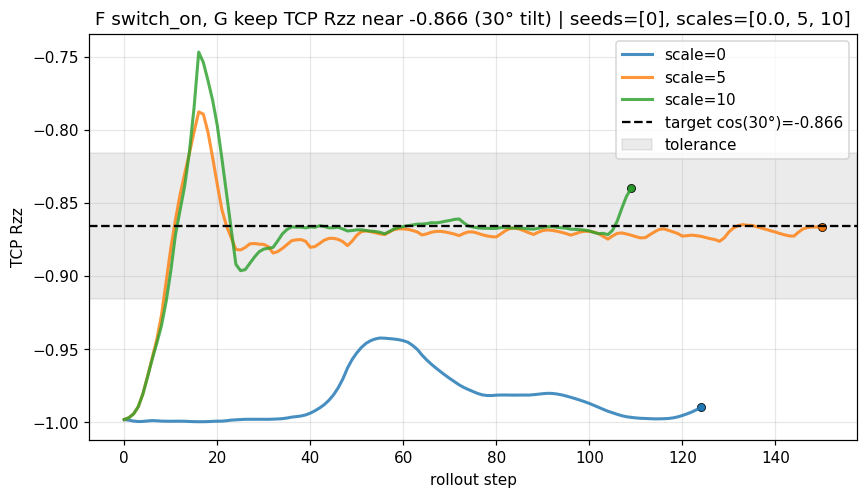

In [11]:
# Plot actual rollout Rzz over time for unguided and Rzz-guided executions.
def plot_rzz_over_time(rollouts, rzz_spec, title, save_path=None):
    scales = sorted({float(r["guidance_scale"]) for r in rollouts})
    cmap = plt.get_cmap("tab10")
    colors = {scale: cmap(i) for i, scale in enumerate(scales)}
    fig, ax = plt.subplots(figsize=(9, 4.8))
    used_labels = set()
    for rollout in rollouts:
        rzz = np.asarray(rollout["tcp_rzz"], dtype=np.float32)
        steps = np.arange(len(rzz))
        scale = float(rollout["guidance_scale"])
        label = f"scale={scale:g}" if scale not in used_labels else None
        used_labels.add(scale)
        ax.plot(steps, rzz, color=colors[scale], linewidth=2.0, alpha=0.82, label=label)
        ax.scatter([steps[-1]], [rzz[-1]], color=colors[scale], s=28, edgecolor="black", linewidth=0.5)
    ax.axhline(rzz_spec.target, color="black", linestyle="--", linewidth=1.5, label=f"target cos({rzz_spec.angle_deg:g}°)={rzz_spec.target:.3f}")
    ax.axhspan(rzz_spec.target - rzz_spec.tolerance, rzz_spec.target + rzz_spec.tolerance, color="black", alpha=0.08, label="tolerance")
    ax.set_title(title)
    ax.set_xlabel("rollout step")
    ax.set_ylabel("TCP Rzz")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print("plot:", save_path)
    png = BytesIO(); fig.savefig(png, format="png", dpi=110, bbox_inches="tight"); plt.close(fig)
    display(Image(data=png.getvalue()))

plot_rzz_over_time(
    rollouts, RZZ_SPEC,
    title=f"F {GOAL_LABEL_NAMES}, G keep TCP Rzz near {RZZ_SPEC.target:.3f} ({RZZ_SPEC.angle_deg:g}° tilt) | seeds={SEEDS}, scales={GUIDANCE_SCALES}",
    save_path=run_dir / "rzz_over_time.png",
)


plot: /home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_switch_G_Rzz/20260521_024744/rollouts_xy.png


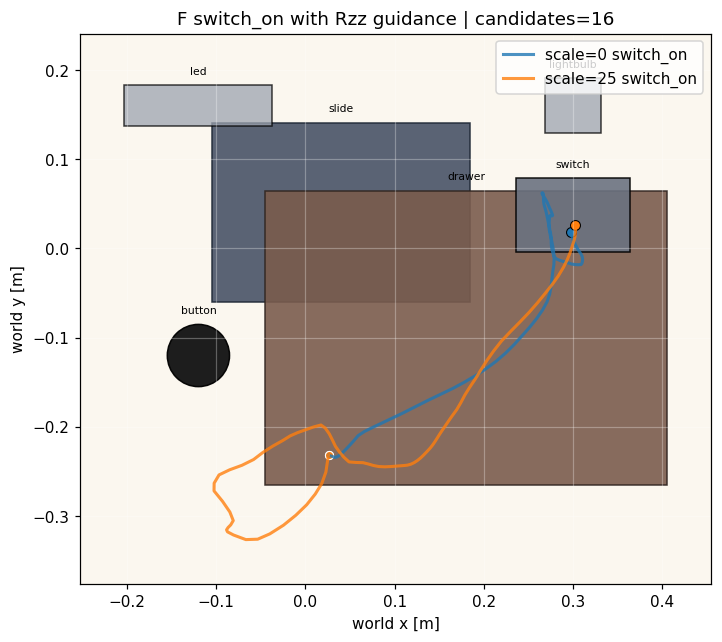

In [7]:
# Optional sanity plot: EEF XY paths, so we can see whether Rzz guidance preserves the switch-reaching behavior.
def plot_rollout_xy(rollouts, scene_snapshot, title, save_path=None):
    scales = sorted({float(r["guidance_scale"]) for r in rollouts})
    cmap = plt.get_cmap("tab10")
    colors = {scale: cmap(i) for i, scale in enumerate(scales)}
    all_xy = np.concatenate([np.asarray(r["eef_xy"], dtype=np.float32) for r in rollouts], axis=0)
    fig, ax = plt.subplots(figsize=(8, 6.5))
    ax.set_facecolor("#fbf7ef")
    CRU.draw_scene_snapshot(ax, scene_snapshot)
    used_labels = set()
    for rollout in rollouts:
        xy = np.asarray(rollout["eef_xy"], dtype=np.float32)
        scale = float(rollout["guidance_scale"])
        label = f"scale={scale:g} {rollout['behavior']}" if scale not in used_labels else None
        used_labels.add(scale)
        ax.plot(xy[:, 0], xy[:, 1], color=colors[scale], linewidth=2.0, alpha=0.8, label=label)
        ax.scatter(xy[0, 0], xy[0, 1], c=[colors[scale]], s=28, edgecolors="white", linewidths=0.7)
        ax.scatter(xy[-1, 0], xy[-1, 1], c=[colors[scale]], s=42, edgecolors="black", linewidths=0.7)
    xlim, ylim = CRU.scene_limits_from_snapshot(scene_snapshot, all_xy)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_title(title); ax.set_xlabel("world x [m]"); ax.set_ylabel("world y [m]"); ax.grid(alpha=0.3); ax.legend(loc="upper right")
    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print("plot:", save_path)
    png = BytesIO(); fig.savefig(png, format="png", dpi=110, bbox_inches="tight"); plt.close(fig)
    display(Image(data=png.getvalue()))

plot_rollout_xy(
    rollouts, rollouts[0]["scene_snapshot"],
    title=f"F {GOAL_LABEL_NAMES} with Rzz guidance | candidates={N_CANDIDATES}",
    save_path=run_dir / "rollouts_xy.png",
)
